# RAG Document Ranking System - NVIDIA NVDocs
## Final Project: Learning-to-Rank for Retrieval-Augmented Generation

**Pipeline Overview:**
1. Data Loading & EDA
2. Data Preparation (flatten into question-chunk-relevance triples)
3. Build Retrieval Indexes (BM25 + FAISS)
4. Feature Engineering
5. Train Ranking Models (Decision Tree, Random Forest, XGBoost, LambdaMART)
6. Evaluation & Comparison
7. End-to-End RAG Demo

## Stage 0: Setup & Install Dependencies

In [1]:
%pip install -q datasets xgboost lightgbm tqdm

Note: you may need to restart the kernel to use updated packages.


## Stage 1: Data Loading & EDA

In [2]:
from datasets import load_dataset

#Load the dataset
dataset = load_dataset("nvidia/Retrieval-Synthetic-NVDocs-v1")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['file_name', 'text', 'chunks', 'sections_structured', 'bundle_id', 'bundle_members', 'is_multi_doc', 'document_artifacts', 'qa_generation', 'deduplicated_qa_pairs', 'qa_evaluations'],
        num_rows: 15095
    })
})


In [3]:
display(dataset['train'][0])

{'file_name': ['researchnvidiacom/research.nvidia.com_publication_2022-11_demystifying-map-space-exploration-npus'],
 'text': 'Map Space Exploration is the problem of finding optimized mappings of a Deep Neural Network (DNN) model on an accelerator. It is known to be extremely computationally expensive, and there has been active research looking at both heuristics and learning-based methods to make the problem computationally tractable. However, while there are dozens of mappers out there (all empirically claiming to find better mappings than others), the research community lacks systematic insights on how different search techniques navigate the map-space and how different mapping axes contribute to the accelerator’s performance and efficiency. Such insights are crucial to developing mapping frameworks for emerging DNNs that are increasingly irregular (due to neural architecture search) and sparse, making the corresponding map spaces much more complex. In this work, rather than propos

In [4]:
from datasets import DatasetDict

full_dataset = dataset['train']

train_testval = full_dataset.train_test_split(test_size=0.2, seed=42)

In [5]:
#Split the 20% 'test_val' into 'validation' (10%) and 'test' (10%)
test_val = train_testval['test'].train_test_split(test_size=0.5, seed=42)

In [6]:
#Gather them all into a new DatasetDict
split_dataset = DatasetDict({
    'train': train_testval['train'],
    'validation': test_val['train'],
    'test': test_val['test']
})

In [7]:
#Display the new splits
print(split_dataset)

DatasetDict({
    train: Dataset({
        features: ['file_name', 'text', 'chunks', 'sections_structured', 'bundle_id', 'bundle_members', 'is_multi_doc', 'document_artifacts', 'qa_generation', 'deduplicated_qa_pairs', 'qa_evaluations'],
        num_rows: 12076
    })
    validation: Dataset({
        features: ['file_name', 'text', 'chunks', 'sections_structured', 'bundle_id', 'bundle_members', 'is_multi_doc', 'document_artifacts', 'qa_generation', 'deduplicated_qa_pairs', 'qa_evaluations'],
        num_rows: 1509
    })
    test: Dataset({
        features: ['file_name', 'text', 'chunks', 'sections_structured', 'bundle_id', 'bundle_members', 'is_multi_doc', 'document_artifacts', 'qa_generation', 'deduplicated_qa_pairs', 'qa_evaluations'],
        num_rows: 1510
    })
})


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

#Convert the train split to a pandas DataFrame for EDA
df = split_dataset['train'].to_pandas()

In [9]:
print("--- Dataset Info ---")
df.info()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12076 entries, 0 to 12075
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   file_name              12076 non-null  object
 1   text                   12076 non-null  object
 2   chunks                 12076 non-null  object
 3   sections_structured    12076 non-null  object
 4   bundle_id              12076 non-null  object
 5   bundle_members         12076 non-null  object
 6   is_multi_doc           12076 non-null  bool  
 7   document_artifacts     12076 non-null  object
 8   qa_generation          12076 non-null  object
 9   deduplicated_qa_pairs  12076 non-null  object
 10  qa_evaluations         12076 non-null  object
dtypes: bool(1), object(10)
memory usage: 955.4+ KB



--- Text Length Distribution ---


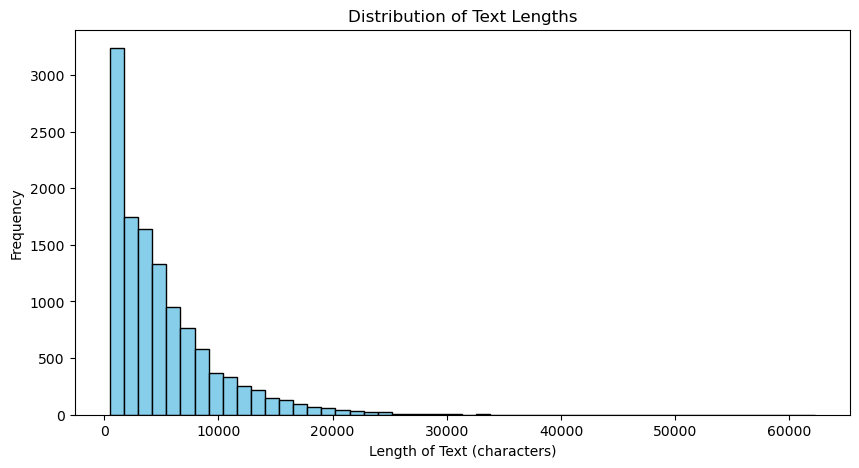

In [10]:
#Distribution of text lengths
print("\n--- Text Length Distribution ---")
df['text_length'] = df['text'].apply(lambda x: len(str(x)))

plt.figure(figsize=(10, 5))
plt.hist(df['text_length'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Text Lengths')
plt.xlabel('Length of Text (characters)')
plt.ylabel('Frequency')
plt.show()

In [11]:
#Distribution of boolean
if 'is_multi_doc' in df.columns:
    print("\n--- 'is_multi_doc' Value Counts ---")
    print(df['is_multi_doc'].value_counts())


--- 'is_multi_doc' Value Counts ---
False    12076
Name: is_multi_doc, dtype: int64


### Deep dive: Understand the QA-Chunk mapping

Each document has chunks and QA pairs. Each QA pair's `segment_ids` tells us which chunks are relevant.
This is our **golden label** — the ground truth for training and evaluation.

In [12]:
# Look at one document's structure
record = split_dataset['train'][0]

print("=== Document Info ===")
print(f"File: {record['file_name']}")
print(f"Number of chunks: {len(record['chunks'])}")
print(f"Number of QA pairs: {len(record['deduplicated_qa_pairs'])}")


=== Document Info ===
File: ['researchnvidiacom/research.nvidia.com_publication_2022-03_gatspi-gpu-accelerated-gate-level-simulation-power-improvement']
Number of chunks: 1
Number of QA pairs: 7


In [13]:
# Show the first QA pair and its relevant chunks
qa = record['deduplicated_qa_pairs'][0]
print(f"\n=== First QA Pair ===")
print(f"Question: {qa['question']}")
print(f"Answer: {qa['answer'][:200]}...")
print(f"Query Type: {qa['query_type']}")
print(f"Reasoning Type: {qa['reasoning_type']}")
print(f"Complexity: {qa['question_complexity']}")
print(f"Hop Count: {qa['hop_count']}")
print(f"Relevant Segment IDs: {qa['segment_ids']}")


=== First QA Pair ===
Question: How does the utilization of GPU acceleration in GATSPI contribute to its significant speedup over commercial simulators, and what role do custom CUDA kernels play in this process?
Answer: GATSPI leverages GPU acceleration through custom CUDA kernels in PyTorch, enabling a simulation kernel speedup of up to 1668X on a single-GPU system and 7412X on multiple-GPU systems compared to comme...
Query Type: multi_hop
Reasoning Type: factual
Complexity: 5
Hop Count: 1
Relevant Segment IDs: [1]


In [14]:
# Show the relevant chunk(s)
chunk_lookup = {c['chunk_id']: c for c in record['chunks']}
print(f"\n=== Relevant Chunk(s) ===")
for sid in qa['segment_ids']:
    if sid in chunk_lookup:
        c = chunk_lookup[sid]
        print(f"\nChunk ID: {sid}")
        print(f"Text preview: {c['text'][:300]}...")
        print(f"Word count: {c['word_count']}, Sentence count: {c['sentence_count']}")


=== Relevant Chunk(s) ===

Chunk ID: 1
Text preview: In this paper, we present GATSPI, a novel GPU accelerated logic gate simulator that enables ultra-fast power estimation for industry sized ASIC designs with millions of gates.. GATSPI is written in PyTorch with custom CUDA kernels for ease of coding and maintainability.. It achieves simulation kerne...
Word count: 140, Sentence count: 5


## Stage 2: Data Preparation — Flatten into (Question, Chunk, Relevance) Triples

We extract all chunks and QA pairs, then create training triples:
- **Positive**: (question, relevant_chunk, 1) — chunk is in `segment_ids`
- **Negative**: (question, random_chunk, 0) — sampled from other chunks

We use 4 negatives per positive to create class imbalance similar to real retrieval.

In [15]:
from data_prep import extract_all_chunks, extract_qa_pairs, create_relevance_triples

# Extract chunks and QA pairs from each split
print("--- Processing TRAIN split ---")
train_chunks = extract_all_chunks(split_dataset['train'])
train_qa = extract_qa_pairs(split_dataset['train'])

print(f"\nTrain: {len(train_chunks)} chunks, {len(train_qa)} QA pairs")

# Also extract from val and test
print("\n--- Processing VALIDATION split ---")
val_chunks = extract_all_chunks(split_dataset['validation'])
val_qa = extract_qa_pairs(split_dataset['validation'])
print(f"Val: {len(val_chunks)} chunks, {len(val_qa)} QA pairs")

print("\n--- Processing TEST split ---")
test_chunks = extract_all_chunks(split_dataset['test'])
test_qa = extract_qa_pairs(split_dataset['test'])
print(f"Test: {len(test_chunks)} chunks, {len(test_qa)} QA pairs")

--- Processing TRAIN split ---


Extracting QA pairs: 100%|██████████| 12076/12076 [00:23<00:00, 522.82it/s]



Train: 96442 chunks, 84485 QA pairs

--- Processing VALIDATION split ---


Extracting QA pairs: 100%|██████████| 1509/1509 [00:02<00:00, 530.37it/s]


Val: 12274 chunks, 10560 QA pairs

--- Processing TEST split ---


Extracting QA pairs: 100%|██████████| 1510/1510 [00:02<00:00, 538.39it/s]

Test: 12162 chunks, 10561 QA pairs


In [16]:
# Build a GLOBAL chunk pool (all chunks from all splits) for negative sampling
# This simulates a real retrieval scenario where you search across the full corpus
all_chunks = train_chunks + val_chunks + test_chunks
print(f"Total chunks in corpus: {len(all_chunks)}")

# Create triples for each split
print("\n--- Creating TRAIN triples ---")
train_triples = create_relevance_triples(train_qa, all_chunks, neg_per_positive=4, seed=42)
print(f"Train triples: {len(train_triples)} ({train_triples['relevance'].sum()} pos, {(train_triples['relevance']==0).sum()} neg)")

print("\n--- Creating VAL triples ---")
val_triples = create_relevance_triples(val_qa, all_chunks, neg_per_positive=4, seed=42)
print(f"Val triples: {len(val_triples)} ({val_triples['relevance'].sum()} pos, {(val_triples['relevance']==0).sum()} neg)")

print("\n--- Creating TEST triples ---")
test_triples = create_relevance_triples(test_qa, all_chunks, neg_per_positive=4, seed=42)
print(f"Test triples: {len(test_triples)} ({test_triples['relevance'].sum()} pos, {(test_triples['relevance']==0).sum()} neg)")

Total chunks in corpus: 120878

--- Creating TRAIN triples ---


Creating triples: 100%|██████████| 84485/84485 [00:03<00:00, 22996.40it/s]


Train triples: 961463 (192291 pos, 769172 neg)

--- Creating VAL triples ---


Creating triples: 100%|██████████| 10560/10560 [00:00<00:00, 28094.30it/s]


Val triples: 121135 (24227 pos, 96908 neg)

--- Creating TEST triples ---


Creating triples: 100%|██████████| 10561/10561 [00:00<00:00, 28537.61it/s]


Test triples: 121250 (24246 pos, 97004 neg)


In [17]:
# Quick sanity check: look at a few triples
print("=== Sample Positive Triple ===")
pos = train_triples[train_triples['relevance'] == 1].iloc[0]
print(f"Question: {pos['question'][:100]}...")
print(f"Chunk: {pos['chunk_text'][:100]}...")
print(f"Relevance: {pos['relevance']}")

print("\n=== Sample Negative Triple ===")
neg = train_triples[train_triples['relevance'] == 0].iloc[0]
print(f"Question: {neg['question'][:100]}...")
print(f"Chunk: {neg['chunk_text'][:100]}...")
print(f"Relevance: {neg['relevance']}")

=== Sample Positive Triple ===
Question: How does the utilization of GPU acceleration in GATSPI contribute to its significant speedup over co...
Chunk: Model Overview
This is an uncased question answering model with a BERT Large encoder finetuned on da...
Relevance: 1

=== Sample Negative Triple ===
Question: How does the utilization of GPU acceleration in GATSPI contribute to its significant speedup over co...
Chunk: Because they're optimized for performance per watt and throughput, rather than absolute performance,...
Relevance: 0


## Stage 3: Build Retrieval Indexes

We build two indexes over the **entire corpus** of chunks:

1. **BM25** (sparse, lexical): Scores based on token overlap (Okapi BM25). Fast, no training needed.
2. **TF-IDF** (sparse, semantic): Uses sklearn's TfidfVectorizer + cosine similarity. Captures term importance.

These scores become **features** for our learning-to-rank models.

In [18]:
from retrieval import BM25Index, TfidfIndex

# Prepare chunk texts and IDs from the full corpus
corpus_texts = [c['chunk_text'] for c in all_chunks]
corpus_ids = [c['chunk_id'] for c in all_chunks]

print(f"Building indexes over {len(corpus_texts)} chunks...")

# 1. Build BM25 index
print("\n--- Building BM25 Index ---")
bm25_index = BM25Index(corpus_texts, corpus_ids)
print("BM25 index ready.")

# 2. Build TF-IDF index
print("\n--- Building TF-IDF Index ---")
tfidf_index = TfidfIndex(max_features=50000, ngram_range=(1, 2))
tfidf_index.build_index(corpus_texts, corpus_ids)

Building indexes over 120878 chunks...

--- Building BM25 Index ---
BM25 index built: 120878 docs, 110482 terms (sparse matrix)
BM25 index ready.

--- Building TF-IDF Index ---
Building TF-IDF index over 120878 chunks...
TF-IDF index built: 120878 docs, 50000 features


In [19]:
# Quick test: retrieve top-5 for a sample question
sample_q = train_qa[0]['question']
print(f"Query: {sample_q}\n")

print("=== BM25 Top-5 ===")
for chunk_id, score in bm25_index.top_k(sample_q, k=5):
    print(f"  {chunk_id}: score={score:.4f}")

print("\n=== TF-IDF Top-5 ===")
for chunk_id, score in tfidf_index.top_k(sample_q, k=5):
    print(f"  {chunk_id}: score={score:.4f}")

# Check if the golden chunk appears in top results
golden_ids = set(train_qa[0]['segment_ids'])
print(f"\nGolden chunk IDs: {golden_ids}")

Query: How does the utilization of GPU acceleration in GATSPI contribute to its significant speedup over commercial simulators, and what role do custom CUDA kernels play in this process?

=== BM25 Top-5 ===
  1: score=45.2301
  4: score=32.4650
  16: score=29.3795
  1: score=28.2134
  2: score=28.1439

=== TF-IDF Top-5 ===
  115: score=0.0674
  66: score=0.0436
  19: score=0.0353
  165: score=0.0350
  169: score=0.0335

Golden chunk IDs: {1}


## Stage 4: Feature Engineering

For each (question, chunk) pair, we compute a feature vector:

| Feature | Type | Source |
|---------|------|--------|
| `bm25_score` | Numeric | BM25 index |
| `cosine_similarity` | Numeric | TF-IDF cosine similarity |
| `token_overlap_ratio` | Numeric | Text overlap |
| `token_overlap_count` | Numeric | Text overlap |
| `question_length` | Numeric | Question metadata |
| `chunk_word_count` | Numeric | Chunk metadata |
| `chunk_sentence_count` | Numeric | Chunk metadata |
| `question_complexity` | Numeric | QA metadata |
| `hop_count` | Numeric | QA metadata |
| `qtype_*` | One-hot | Query type |
| `rtype_*` | One-hot | Reasoning type |

The ranking models will learn which combinations of these features predict relevance.

In [20]:
from features import compute_features, get_feature_columns

# Compute TRAIN features only — val and test computed later when needed
print("--- Computing TRAIN features ---")
train_featured = compute_features(train_triples, bm25_index, tfidf_index)
print(f"\nTrain shape: {train_featured.shape}")

--- Computing TRAIN features ---
Computing features for 961463 pairs (84474 unique questions)...
BM25 scoring (pair-wise)...
  BM25 scores computed: (961463,)
TF-IDF scoring (pair-wise)...
  TF-IDF scores computed: (961463,)
Computing text overlap features...

Train shape: (961463, 26)


In [21]:
# Inspect the features
feature_cols = get_feature_columns(train_featured)
print(f"Feature columns ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  - {col}")

print(f"\n--- Feature Statistics (Train) ---")
train_featured[feature_cols].describe().round(3)

Feature columns (19):
  - question_complexity
  - hop_count
  - chunk_word_count
  - chunk_sentence_count
  - bm25_score
  - cosine_similarity
  - token_overlap_ratio
  - token_overlap_count
  - question_length
  - qtype_contextual
  - qtype_multi_hop
  - qtype_structural
  - rtype_causal
  - rtype_factual
  - rtype_inferential
  - rtype_procedural
  - rtype_relational
  - rtype_temporal
  - rtype_visual

--- Feature Statistics (Train) ---


,question_complexity,hop_count,chunk_word_count,chunk_sentence_count,bm25_score,cosine_similarity,token_overlap_ratio,token_overlap_count,question_length,qtype_contextual,qtype_multi_hop,qtype_structural,rtype_causal,rtype_factual,rtype_inferential,rtype_procedural,rtype_relational,rtype_temporal,rtype_visual
count,961463.000,961463.000,961463.000,961463.000,961463.000,961463.000,961463.000,961463.000,961463.000,961463.000,961463.000,961463.000,961463.000,961463.000,961463.000,961463.000,961463.000,961463.000,961463.000
mean,4.913,1.827,49.574,4.890,2.297,0.004,0.085,2.012,26.877,0.264,0.474,0.262,0.190,0.114,0.219,0.140,0.211,0.092,0.035
std,0.281,0.920,58.923,0.542,3.091,0.011,0.089,2.113,5.915,0.441,0.499,0.440,0.392,0.318,0.414,0.347,0.408,0.289,0.183
min,4.000,1.000,3.000,1.000,0.000,0.000,0.000,0.000,10.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,5.000,1.000,16.000,5.000,0.000,0.000,0.000,0.000,23.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,5.000,2.000,28.000,5.000,1.093,0.000,0.050,1.000,26.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,5.000,3.000,74.000,5.000,3.368,0.000,0.148,3.000,31.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
max,5.000,7.000,626.000,5.000,66.257,0.707,0.619,14.000,63.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


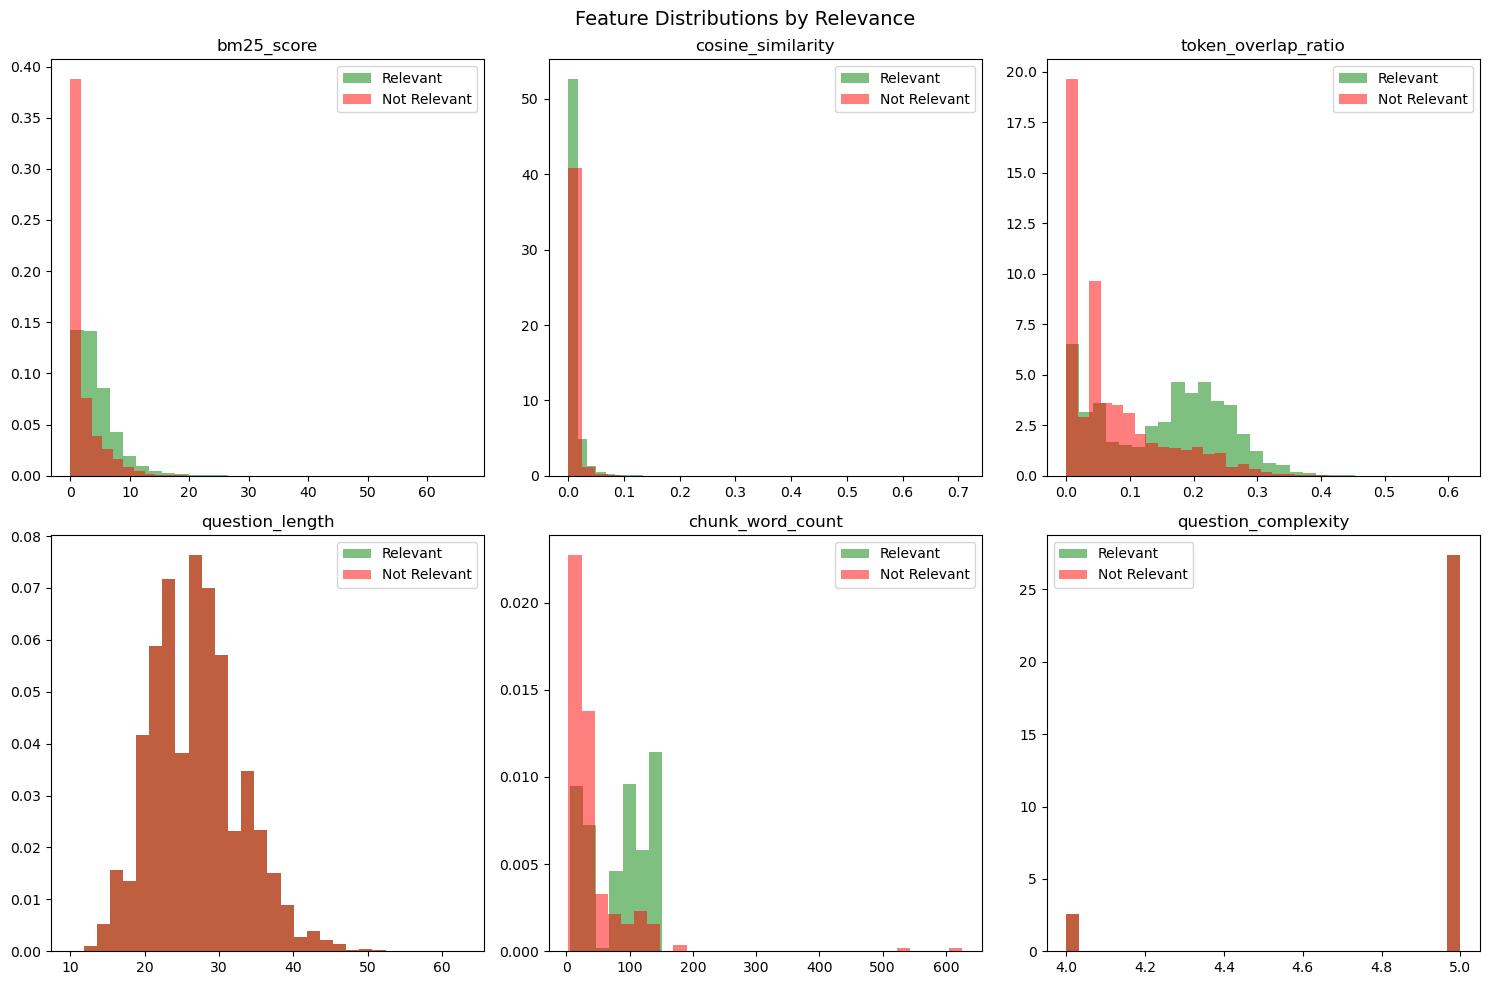

In [22]:
import seaborn as sns

# Visualize feature distributions by relevance
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
key_features = ['bm25_score', 'cosine_similarity', 'token_overlap_ratio',
                'question_length', 'chunk_word_count', 'question_complexity']

for ax, feat in zip(axes.flat, key_features):
    for rel, color, label in [(1, 'green', 'Relevant'), (0, 'red', 'Not Relevant')]:
        subset = train_featured[train_featured['relevance'] == rel][feat]
        ax.hist(subset, bins=30, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(feat)
    ax.legend()

plt.suptitle('Feature Distributions by Relevance', fontsize=14)
plt.tight_layout()
plt.show()

## Stage 5: Train Ranking Models

We train multiple models to predict relevance scores, then rank chunks by score.

**Models:**
1. **BM25 Baseline** — no training, just use BM25 scores directly
2. **TF-IDF Baseline** — no training, just use TF-IDF cosine similarity
3. **Decision Tree** — simple tree-based classifier
4. **Random Forest** — ensemble of trees
5. **XGBoost Ranker** — gradient-boosted trees with ranking objective (LambdaMART)
6. **LightGBM Ranker** — alternative LambdaMART implementation

For the tree models, we train a binary classifier (relevant vs not) and use `predict_proba` as the ranking score.
For XGBoost/LightGBM, we use their native ranking objectives which optimize NDCG directly.

In [23]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from evaluate import evaluate_ranking, print_evaluation

# Compute VALIDATION features — needed for model selection / tuning
print("--- Computing VAL features ---")
val_featured = compute_features(val_triples, bm25_index, tfidf_index)
print(f"Val shape: {val_featured.shape}")

# Prepare feature matrices
feature_cols = get_feature_columns(train_featured)

# Align feature columns across splits (handle missing one-hot columns)
for col in feature_cols:
    if col not in val_featured.columns:
        val_featured[col] = 0

X_train = train_featured[feature_cols].values
y_train = train_featured['relevance'].values
X_val = val_featured[feature_cols].values
y_val = val_featured['relevance'].values

print(f"\nX_train: {X_train.shape}, X_val: {X_val.shape}")

--- Computing VAL features ---
Computing features for 121135 pairs (10560 unique questions)...
BM25 scoring (pair-wise)...
  BM25 scores computed: (121135,)
TF-IDF scoring (pair-wise)...
  TF-IDF scores computed: (121135,)
Computing text overlap features...
Val shape: (121135, 26)

X_train: (961463, 19), X_val: (121135, 19)


### 5a. Baselines: BM25 and TF-IDF Cosine Similarity

No training — just use the raw retrieval scores as ranking scores.

In [24]:
# Evaluate BM25 baseline on validation set
bm25_val_metrics = evaluate_ranking(val_featured, 'bm25_score', k_values=[5, 10, 20])
print_evaluation(bm25_val_metrics, "BM25 Baseline (Val)")

# Evaluate TF-IDF cosine similarity baseline on validation set
tfidf_val_metrics = evaluate_ranking(val_featured, 'cosine_similarity', k_values=[5, 10, 20])
print_evaluation(tfidf_val_metrics, "TF-IDF Cosine Similarity Baseline (Val)")


  BM25 Baseline (Val) Evaluation Results
  MAP            : 0.6060
  MRR            : 0.6449
  NDCG@10        : 0.7115
  NDCG@20        : 0.7310
  NDCG@5         : 0.6417
  Recall@10      : 0.9462
  Recall@20      : 0.9962
  Recall@5       : 0.7898

  TF-IDF Cosine Similarity Baseline (Val) Evaluation Results
  MAP            : 0.6684
  MRR            : 0.6717
  NDCG@10        : 0.7565
  NDCG@20        : 0.7677
  NDCG@5         : 0.7206
  Recall@10      : 0.9652
  Recall@20      : 0.9938
  Recall@5       : 0.8893


### 5b. Decision Tree Classifier

In [25]:
# Train a Decision Tree classifier
dt_model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, random_state=42)
dt_model.fit(X_train, y_train)

# Use predict_proba[:, 1] (probability of relevance=1) as ranking score
val_featured['dt_score'] = dt_model.predict_proba(X_val)[:, 1]

dt_val_metrics = evaluate_ranking(val_featured, 'dt_score', k_values=[5, 10, 20])
print_evaluation(dt_val_metrics, "Decision Tree (Val)")

# Feature importance
dt_importance = pd.Series(dt_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nTop 10 Feature Importances (Decision Tree):")
print(dt_importance.head(10))


  Decision Tree (Val) Evaluation Results
  MAP            : 0.9519
  MRR            : 0.9667
  NDCG@10        : 0.9703
  NDCG@20        : 0.9709
  NDCG@5         : 0.9625
  Recall@10      : 0.9984
  Recall@20      : 0.9999
  Recall@5       : 0.9819

Top 10 Feature Importances (Decision Tree):
chunk_word_count        0.893330
cosine_similarity       0.040408
chunk_sentence_count    0.032778
bm25_score              0.025899
token_overlap_count     0.005108
hop_count               0.000971
token_overlap_ratio     0.000582
question_length         0.000408
qtype_multi_hop         0.000129
rtype_visual            0.000123
dtype: float64


### 5c. Random Forest Classifier

In [26]:
# Train a Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

val_featured['rf_score'] = rf_model.predict_proba(X_val)[:, 1]

rf_val_metrics = evaluate_ranking(val_featured, 'rf_score', k_values=[5, 10, 20])
print_evaluation(rf_val_metrics, "Random Forest (Val)")

# Feature importance
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nTop 10 Feature Importances (Random Forest):")
print(rf_importance.head(10))


  Random Forest (Val) Evaluation Results
  MAP            : 0.9226
  MRR            : 0.9559
  NDCG@10        : 0.9521
  NDCG@20        : 0.9547
  NDCG@5         : 0.9346
  Recall@10      : 0.9933
  Recall@20      : 0.9996
  Recall@5       : 0.9553

Top 10 Feature Importances (Random Forest):
chunk_word_count        0.606953
token_overlap_ratio     0.105914
bm25_score              0.102240
cosine_similarity       0.067494
token_overlap_count     0.058378
chunk_sentence_count    0.039892
question_length         0.006923
hop_count               0.004312
rtype_procedural        0.001325
qtype_multi_hop         0.001298
dtype: float64


### 5d. XGBoost Ranker (LambdaMART)

XGBoost's `rank:ndcg` objective directly optimizes NDCG — the key ranking metric.
It needs a `group` parameter telling it which rows belong to the same query.

In [27]:
import xgboost as xgb

# XGBoost ranking needs group sizes: how many rows per query
# Sort by question to group them together
train_sorted = train_featured.sort_values('question').reset_index(drop=True)
val_sorted = val_featured.sort_values('question').reset_index(drop=True)

train_groups = train_sorted.groupby('question').size().values
val_groups = val_sorted.groupby('question').size().values

X_train_sorted = train_sorted[feature_cols].values
y_train_sorted = train_sorted['relevance'].values
X_val_sorted = val_sorted[feature_cols].values
y_val_sorted = val_sorted['relevance'].values

# Train XGBoost ranker
xgb_model = xgb.XGBRanker(
    objective='rank:ndcg',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
)

xgb_model.fit(
    X_train_sorted, y_train_sorted,
    group=train_groups,
    eval_set=[(X_val_sorted, y_val_sorted)],
    eval_group=[val_groups],
    verbose=50
)

# Score validation set
val_featured['xgb_score'] = xgb_model.predict(X_val)
xgb_val_metrics = evaluate_ranking(val_featured, 'xgb_score', k_values=[5, 10, 20])
print_evaluation(xgb_val_metrics, "XGBoost Ranker (Val)")

[0]	validation_0-ndcg@32:0.95421
[50]	validation_0-ndcg@32:0.96863
[100]	validation_0-ndcg@32:0.97079
[150]	validation_0-ndcg@32:0.97201
[200]	validation_0-ndcg@32:0.97258
[250]	validation_0-ndcg@32:0.97284
[299]	validation_0-ndcg@32:0.97290

  XGBoost Ranker (Val) Evaluation Results
  MAP            : 0.9562
  MRR            : 0.9692
  NDCG@10        : 0.9730
  NDCG@20        : 0.9735
  NDCG@5         : 0.9667
  Recall@10      : 0.9987
  Recall@20      : 1.0000
  Recall@5       : 0.9852


### 5e. LightGBM Ranker (LambdaMART)

In [28]:
import lightgbm as lgb

lgb_model = lgb.LGBMRanker(
    objective='lambdarank',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

lgb_model.fit(
    X_train_sorted, y_train_sorted,
    group=train_groups,
    eval_set=[(X_val_sorted, y_val_sorted)],
    eval_group=[val_groups],
    eval_at=[5, 10, 20],
)

val_featured['lgb_score'] = lgb_model.predict(X_val)
lgb_val_metrics = evaluate_ranking(val_featured, 'lgb_score', k_values=[5, 10, 20])
print_evaluation(lgb_val_metrics, "LightGBM Ranker (Val)")


  LightGBM Ranker (Val) Evaluation Results
  MAP            : 0.9568
  MRR            : 0.9694
  NDCG@10        : 0.9734
  NDCG@20        : 0.9738
  NDCG@5         : 0.9674
  Recall@10      : 0.9990
  Recall@20      : 1.0000
  Recall@5       : 0.9860


## Stage 6: Model Comparison & Final Test Evaluation

Compare all models side-by-side on validation, pick the best, then do final evaluation on the held-out test set.

In [29]:
# Collect all validation metrics into a comparison table
all_val_metrics = {
    'BM25 Baseline': bm25_val_metrics,
    'TF-IDF Cosine': tfidf_val_metrics,
    'Decision Tree': dt_val_metrics,
    'Random Forest': rf_val_metrics,
    'XGBoost Ranker': xgb_val_metrics,
    'LightGBM Ranker': lgb_val_metrics,
}

comparison_df = pd.DataFrame(all_val_metrics).T
comparison_df = comparison_df.round(4)
print("=== Validation Set: Model Comparison ===")
display(comparison_df)

=== Validation Set: Model Comparison ===


,NDCG@5,NDCG@10,NDCG@20,Recall@5,Recall@10,Recall@20,MRR,MAP
BM25 Baseline,0.6417,0.7115,0.7310,0.7898,0.9462,0.9962,0.6449,0.6060
TF-IDF Cosine,0.7206,0.7565,0.7677,0.8893,0.9652,0.9938,0.6717,0.6684
Decision Tree,0.9625,0.9703,0.9709,0.9819,0.9984,0.9999,0.9667,0.9519
Random Forest,0.9346,0.9521,0.9547,0.9553,0.9933,0.9996,0.9559,0.9226
XGBoost Ranker,0.9667,0.9730,0.9735,0.9852,0.9987,1.0000,0.9692,0.9562
LightGBM Ranker,0.9674,0.9734,0.9738,0.9860,0.9990,1.0000,0.9694,0.9568


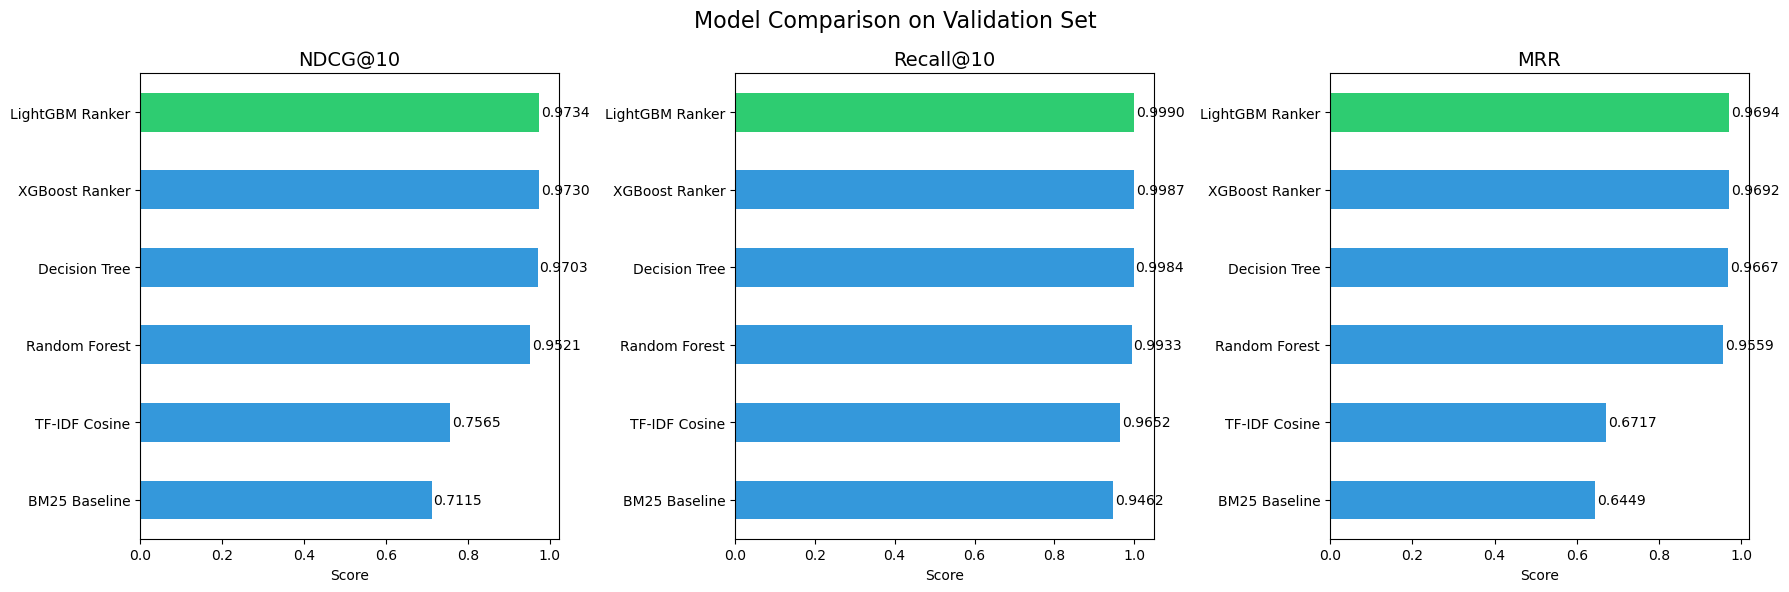

In [30]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_to_plot = ['NDCG@10', 'Recall@10', 'MRR']
for ax, metric in zip(axes, metrics_to_plot):
    values = comparison_df[metric].sort_values(ascending=True)
    colors = ['#2ecc71' if v == values.max() else '#3498db' for v in values]
    values.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(metric, fontsize=14)
    ax.set_xlabel('Score')
    for i, v in enumerate(values):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center')

plt.suptitle('Model Comparison on Validation Set', fontsize=16)
plt.tight_layout()
plt.show()

### Final Test Evaluation (Best Model)

We pick the best model based on validation NDCG@10 and evaluate on the test set.
**This is the only time we touch the test set** — prevents data leakage.

In [31]:
# Compute TEST features — only now, at final evaluation time
print("--- Computing TEST features ---")
test_featured = compute_features(test_triples, bm25_index, tfidf_index)
print(f"Test shape: {test_featured.shape}")

# Align feature columns
for col in feature_cols:
    if col not in test_featured.columns:
        test_featured[col] = 0

X_test = test_featured[feature_cols].values
y_test = test_featured['relevance'].values

# Determine best model by val NDCG@10
best_model_name = comparison_df['NDCG@10'].idxmax()
print(f"\nBest model (by Val NDCG@10): {best_model_name}")

# Score test set with ALL models for comparison
test_featured['bm25_score_raw'] = test_featured['bm25_score']
test_featured['tfidf_score_raw'] = test_featured['cosine_similarity']
test_featured['dt_score'] = dt_model.predict_proba(X_test)[:, 1]
test_featured['rf_score'] = rf_model.predict_proba(X_test)[:, 1]
test_featured['xgb_score'] = xgb_model.predict(X_test)
test_featured['lgb_score'] = lgb_model.predict(X_test)

# Evaluate all on test
test_metrics = {}
score_cols = {
    'BM25 Baseline': 'bm25_score',
    'TF-IDF Cosine': 'cosine_similarity',
    'Decision Tree': 'dt_score',
    'Random Forest': 'rf_score',
    'XGBoost Ranker': 'xgb_score',
    'LightGBM Ranker': 'lgb_score',
}
for name, col in score_cols.items():
    test_metrics[name] = evaluate_ranking(test_featured, col, k_values=[5, 10, 20])

test_comparison_df = pd.DataFrame(test_metrics).T.round(4)
print("\n=== TEST Set: Final Model Comparison ===")
display(test_comparison_df)

--- Computing TEST features ---
Computing features for 121250 pairs (10559 unique questions)...
BM25 scoring (pair-wise)...
  BM25 scores computed: (121250,)
TF-IDF scoring (pair-wise)...
  TF-IDF scores computed: (121250,)
Computing text overlap features...
Test shape: (121250, 26)

Best model (by Val NDCG@10): LightGBM Ranker

=== TEST Set: Final Model Comparison ===


,NDCG@5,NDCG@10,NDCG@20,Recall@5,Recall@10,Recall@20,MRR,MAP
BM25 Baseline,0.6446,0.7136,0.7327,0.7928,0.9467,0.9961,0.6464,0.6094
TF-IDF Cosine,0.7175,0.7547,0.7670,0.8844,0.9629,0.9945,0.6713,0.6669
Decision Tree,0.9612,0.9691,0.9696,0.9817,0.9980,0.9993,0.9647,0.9503
Random Forest,0.9334,0.9507,0.9534,0.9556,0.9924,0.9992,0.9524,0.9220
XGBoost Ranker,0.9659,0.9725,0.9729,0.9847,0.9984,0.9994,0.9683,0.9556
LightGBM Ranker,0.9667,0.9730,0.9733,0.9855,0.9985,0.9994,0.9687,0.9564


In [32]:
# Analyze performance by query type and reasoning type
print("=== Performance Breakdown by Query Type (Best Model) ===\n")

# Use the best model's score column
best_score_col = score_cols[best_model_name]

for qtype in test_featured['query_type'].unique():
    subset = test_featured[test_featured['query_type'] == qtype]
    if len(subset) > 0:
        metrics = evaluate_ranking(subset, best_score_col, k_values=[10])
        print(f"  {qtype:20s} — NDCG@10: {metrics['NDCG@10']:.4f}, Recall@10: {metrics['Recall@10']:.4f}, n={len(subset)}")

print("\n=== Performance Breakdown by Reasoning Type ===\n")
for rtype in test_featured['reasoning_type'].unique():
    subset = test_featured[test_featured['reasoning_type'] == rtype]
    if len(subset) > 0:
        metrics = evaluate_ranking(subset, best_score_col, k_values=[10])
        print(f"  {rtype:20s} — NDCG@10: {metrics['NDCG@10']:.4f}, Recall@10: {metrics['Recall@10']:.4f}, n={len(subset)}")

=== Performance Breakdown by Query Type (Best Model) ===

  multi_hop            — NDCG@10: 0.9759, Recall@10: 0.9985, n=57815
  structural           — NDCG@10: 0.9725, Recall@10: 0.9989, n=31668
  contextual           — NDCG@10: 0.9692, Recall@10: 0.9979, n=31767

=== Performance Breakdown by Reasoning Type ===

  inferential          — NDCG@10: 0.9741, Recall@10: 0.9980, n=26089
  relational           — NDCG@10: 0.9792, Recall@10: 0.9988, n=24698
  causal               — NDCG@10: 0.9741, Recall@10: 0.9989, n=22949
  factual              — NDCG@10: 0.9788, Recall@10: 0.9991, n=14024
  procedural           — NDCG@10: 0.9624, Recall@10: 0.9981, n=17320
  visual               — NDCG@10: 0.9610, Recall@10: 0.9969, n=4545
  temporal             — NDCG@10: 0.9677, Recall@10: 0.9985, n=11625


## Stage 7: End-to-End RAG Retrieval Demo

Given a new question:
1. **First-stage retrieval**: Use TF-IDF to get top-50 candidate chunks (fast, broad recall)
2. **Feature computation**: Compute features for each (question, candidate) pair
3. **Re-rank**: Use the best trained model to re-score and re-rank
4. **Return top-K**: Final ranked list of most relevant chunks

In [33]:
from features import compute_text_overlap

def rag_retrieve(question, tfidf_index, bm25_index, model, feature_cols,
                 candidate_k=50, final_k=5):
    """
    End-to-end retrieval: first-stage TF-IDF retrieval + learned re-ranking.
    
    Args:
        question: query string
        tfidf_index: TfidfIndex with the corpus
        bm25_index: BM25Index with the corpus
        model: trained sklearn/xgb/lgb model with .predict() method
        feature_cols: list of feature column names
        candidate_k: how many candidates to retrieve in first stage
        final_k: how many to return after re-ranking
    
    Returns:
        list of (chunk_id, chunk_text, score) tuples
    """
    # 1. First-stage: TF-IDF retrieval
    candidates = tfidf_index.top_k(question, k=candidate_k)
    
    # 2. Build feature rows for each candidate
    chunk_lookup = {c['chunk_id']: c for c in all_chunks}
    bm25_scores = bm25_index.score(question)
    rows = []
    for chunk_id, cosine_score in candidates:
        chunk = chunk_lookup[chunk_id]
        overlap = compute_text_overlap(question, chunk['chunk_text'])
        
        row = {
            'bm25_score': bm25_scores.get(chunk_id, 0.0),
            'cosine_similarity': cosine_score,
            'token_overlap_ratio': overlap['token_overlap_ratio'],
            'token_overlap_count': overlap['token_overlap_count'],
            'question_length': len(question.split()),
            'chunk_word_count': chunk['word_count'],
            'chunk_sentence_count': chunk['sentence_count'],
            'question_complexity': 3,  # default for unknown questions
            'hop_count': 1,
        }
        rows.append((chunk_id, chunk['chunk_text'], row))
    
    # 3. Create feature matrix
    feature_rows = pd.DataFrame([r[2] for r in rows])
    # Add any missing one-hot columns with 0
    for col in feature_cols:
        if col not in feature_rows.columns:
            feature_rows[col] = 0
    feature_rows = feature_rows[feature_cols]
    
    # 4. Re-rank with trained model
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(feature_rows.values)[:, 1]
    else:
        scores = model.predict(feature_rows.values)
    
    # 5. Sort by score and return top-K
    results = [(rows[i][0], rows[i][1], float(scores[i])) for i in range(len(rows))]
    results.sort(key=lambda x: x[2], reverse=True)
    return results[:final_k]


# Demo: try a question from the test set
demo_question = test_qa[0]['question']
demo_golden = set(test_qa[0]['segment_ids'])

print(f"Query: {demo_question}\n")
print(f"Golden relevant chunks: {demo_golden}\n")

# Pick the best model object
model_objects = {
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'XGBoost Ranker': xgb_model,
    'LightGBM Ranker': lgb_model,
}
best_model = model_objects.get(best_model_name, xgb_model)

results = rag_retrieve(demo_question, tfidf_index, bm25_index, best_model, feature_cols)

print(f"=== Top-5 Retrieved Chunks ({best_model_name}) ===\n")
for rank, (chunk_id, text, score) in enumerate(results, 1):
    is_relevant = "RELEVANT" if chunk_id in demo_golden else ""
    print(f"Rank {rank}: {chunk_id} (score={score:.4f}) {is_relevant}")
    print(f"  {text[:150]}...")
    print()

Query: How does the NVIDIA Open Model License's approach to ownership of outputs and derivative models impact the development of commercial AI applications using Cosmos-Tokenize1?

Golden relevant chunks: {8, 1, 2, 9}

=== Top-5 Retrieved Chunks (LightGBM Ranker) ===

Rank 1: 1 (score=3.6597) RELEVANT
  Model Overview
This is an uncased question answering model with a BERT Large encoder finetuned on dataset SQuADv2.0 [1].. With Question Answering, or ...

Rank 2: 2 (score=3.1068) RELEVANT
  In this particular instance, the model has 24 Transformer blocks.. On top of that it is using a span prediction head, that is equivalent to token clas...

Rank 3: 3 (score=2.7059) 
  Dataset
The model was trained on SQuADv2.0 [1] corpus for question answering.. For datasets like SQuAD 2.0, this model supports cases when the answer ...

Rank 4: 4 (score=2.6060) 
  Limitations
The length of the input text is currently constrained by the maximum sequence length of the uncased encoder model, which is 51